# Chapter 1: Introduction

**Source orientation.** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 1, printed pp. 1-16; PDF pp. 16-31. This notebook uses that span as an orientation map only; the prose, diagrams, computations, and checks below are original.

**Chapter question.** How does a local Cauchy-Riemann type equation become a global symplectic invariant?

Chapter 1 is not just a list of later topics. It sets up the pipeline that the rest of the course keeps revisiting: a symplectic form supplies area, a tame almost complex structure turns tangent planes into complex lines, regularity turns solutions into a finite-dimensional moduli space, compactness controls limits, evaluation maps turn curves into geometric cycles, and intersection numbers become Gromov-Witten invariants.


## Source Coverage

| Section | Standalone coverage in this notebook | Visual or check |
| --- | --- | --- |
| 1.1 Symplectic manifolds | Symplectic form, Darboux local model, tame almost complex structures, and why a J-holomorphic curve is automatically symplectic. | Taming-positive-area diagram and matrix positivity check. |
| 1.2 Moduli spaces | Simple curves, regularity, Fredholm dimension, compactness, and why transversality plus compactness are both required before counting. | Pipeline graph and dimension-gate table. |
| 1.3 Evaluation maps and pseudocycles | Evaluation at one or many marked points, pseudocycle language, and the nonsqueezing use case as a motivating application. | Evaluation/constraint dimension ledger. |
| 1.4 Gromov-Witten invariants | Intersect the evaluation pseudocycle with product constraints; deformation invariance and splitting are signposts for later chapters. | Zero-dimensional count check. |
| 1.5 Applications and developments | Later uses: nonsqueezing, symplectic 4-manifolds, quantum cohomology, Floer theory, and vortex equations. | Course dependency graph. |

The coverage JSON written below is a machine-readable promise: each section has a named notebook object and at least one validation target. That makes missing chapter material visible during QC instead of hidden in pleasant prose.


## Library Routing

| Concept | Representation | Library | Why this route fits |
| --- | --- | --- | --- |
| Taming condition | Vector, J-rotation, oriented parallelogram, quadratic positivity | NumPy + Matplotlib | The condition is pointwise linear algebra and an annotated planar plot is more inspectable than a symbolic wall. |
| Regularity/compactness/evaluation pipeline | Directed dependency graph | NetworkX + Matplotlib | The introduction is a map of dependencies; a graph lets the learner see which later chapters supply each gate. |
| GW count dimension balance | Table and bar ledger | pandas + Matplotlib | Counting begins only after dimensions cancel; a ledger makes each subtraction explicit. |
| Sanity checks | JSON summaries and artifact assertions | stdlib JSON + course helpers | The notebook should leave durable evidence that visuals and invariants agree. |


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        candidate = base if base.name == "J-Holomorphic-Curves-and-Symplectic-Topology" else base / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists():
            return candidate
    raise RuntimeError("Could not locate JHCST book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_dir, assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-01"
FIG_DIR = artifact_dir(UNIT, "figures")
CHECK_DIR = artifact_dir(UNIT, "checks")
TABLE_DIR = artifact_dir(UNIT, "tables")

coverage = [
    {"section": "1.1", "topic": "symplectic form and tame almost complex structure", "notebook_object": "taming-positive-area.png", "check": "omega(v,Jv)>0 for sampled vectors"},
    {"section": "1.2", "topic": "regularity and compactness gates for moduli spaces", "notebook_object": "gw-course-pipeline.png", "check": "all pipeline gates have later source anchors"},
    {"section": "1.3", "topic": "evaluation maps and pseudocycles", "notebook_object": "gw-dimension-ledger.png", "check": "dimension ledger reaches zero for the toy count"},
    {"section": "1.4", "topic": "Gromov-Witten invariant as an intersection number", "notebook_object": "invariant-ledger.csv", "check": "constraints match expected dimension"},
    {"section": "1.5", "topic": "applications: nonsqueezing, quantum products, Floer/vortex directions", "notebook_object": "gw-course-pipeline.png", "check": "applications attach to the relevant theorem gates"},
]
source_coverage_path = save_json({"unit": UNIT, "source_span": "printed pp. 1-16; PDF pp. 16-31", "sections": coverage, "passed": all(row["check"] for row in coverage)}, UNIT, "checks", "source-coverage.json")

storyboard = [
    {"visual": "taming-positive-area.png", "concept": "tame J makes every complex line carry positive symplectic area", "inspection_target": "orientation of v,Jv and positive area label", "validation": "positive quadratic form on sampled vectors"},
    {"visual": "gw-course-pipeline.png", "concept": "regularity, compactness, evaluation, and pseudocycle steps are separate gates", "inspection_target": "path from local equation to invariant count", "validation": "every gate has a source-section anchor"},
    {"visual": "gw-dimension-ledger.png", "concept": "point constraints can turn a moduli space into a zero-dimensional count", "inspection_target": "dimension bars before and after constraints", "validation": "final dimension equals zero"},
]
visual_storyboard_path = save_json({"unit": UNIT, "storyboard": storyboard, "passed": len(storyboard) >= 3}, UNIT, "checks", "visual-storyboard.json")

source_coverage_path, visual_storyboard_path

(WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/chapter-01/checks/source-coverage.json'),
 WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/chapter-01/checks/visual-storyboard.json'))

## Taming: Local Linear Algebra With Global Consequences

A symplectic form alone gives signed area, while an almost complex structure alone gives a notion of complex line. The taming condition asks these two structures to agree on orientation: every nonzero tangent vector and its J-rotation span a positively oriented symplectic parallelogram. This is the local reason a J-holomorphic curve carries positive symplectic area instead of arbitrary signed area.

The finite model below uses the standard plane. It is deliberately small because the actual condition is pointwise: if the matrix check fails in one tangent plane, the geometric setup has already lost the positivity needed for energy and compactness arguments.


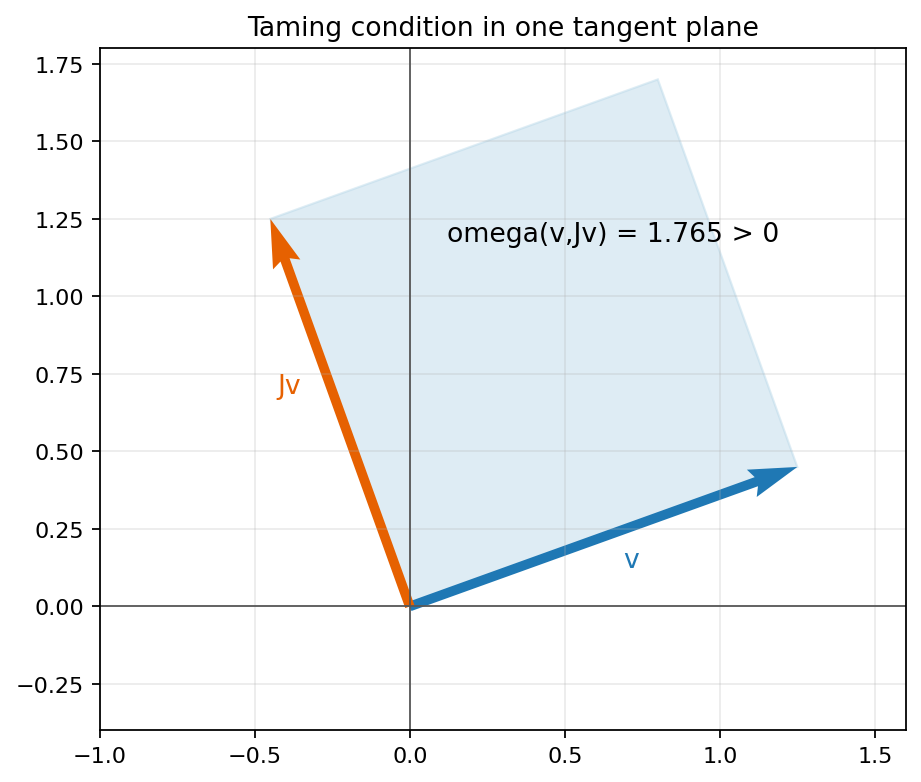

{'sample_count': 4,
 'minimum_omega_v_Jv': 1.04,
 'matrix_identity_J_squared': True,
 'passed': True}

In [2]:
Omega = np.array([[0.0, 1.0], [-1.0, 0.0]])
J0 = np.array([[0.0, -1.0], [1.0, 0.0]])

samples = np.array([
    [1.0, 0.2],
    [0.4, 1.1],
    [-0.8, 0.7],
    [1.3, -0.6],
])
areas = np.array([v @ Omega @ (J0 @ v) for v in samples])
assert np.all(areas > 0)

v = np.array([1.25, 0.45])
Jv = J0 @ v
parallelogram = np.array([[0, 0], v, v + Jv, Jv, [0, 0]])

fig, ax = plt.subplots(figsize=(6.5, 6.2))
ax.fill(parallelogram[:, 0], parallelogram[:, 1], color="#b7d7e8", alpha=0.45, label="symplectic area")
ax.quiver([0, 0], [0, 0], [v[0], Jv[0]], [v[1], Jv[1]], angles="xy", scale_units="xy", scale=1, color=["#1f78b4", "#e66101"], width=0.012)
ax.text(v[0] * 0.55, v[1] * 0.55 - 0.12, "v", color="#1f78b4", fontsize=12)
ax.text(Jv[0] * 0.55 - 0.18, Jv[1] * 0.55, "Jv", color="#e66101", fontsize=12)
ax.text(0.12, 1.18, f"omega(v,Jv) = {v @ Omega @ Jv:.3f} > 0", fontsize=12)
ax.axhline(0, color="#555", linewidth=0.8)
ax.axvline(0, color="#555", linewidth=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.0, 1.6)
ax.set_ylim(-0.4, 1.8)
ax.set_title("Taming condition in one tangent plane")
ax.grid(True, alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "taming-positive-area.png")
plt.close(fig)

taming_check = {
    "sample_count": int(len(samples)),
    "minimum_omega_v_Jv": float(areas.min()),
    "matrix_identity_J_squared": np.allclose(J0 @ J0, -np.eye(2)),
    "passed": bool(np.all(areas > 0) and np.allclose(J0 @ J0, -np.eye(2))),
}
taming_check_path = save_json(taming_check, UNIT, "checks", "taming-area-checks.json")
display_artifact(fig_path)
taming_check

## From Curves to Counts

The chapter separates four gates that are easy to blur together. First, the Cauchy-Riemann equation defines curves. Second, regularity says the solution space is a manifold of the predicted dimension. Third, compactness says sequences have controlled limits; when compactness fails, later chapters replace missing limits by stable maps. Fourth, evaluation maps turn marked curves into geometric representatives that can be intersected with constraints.

Read the graph as a workflow, not as a proof. It tells you which later chapters pay for each promise made in the introduction.


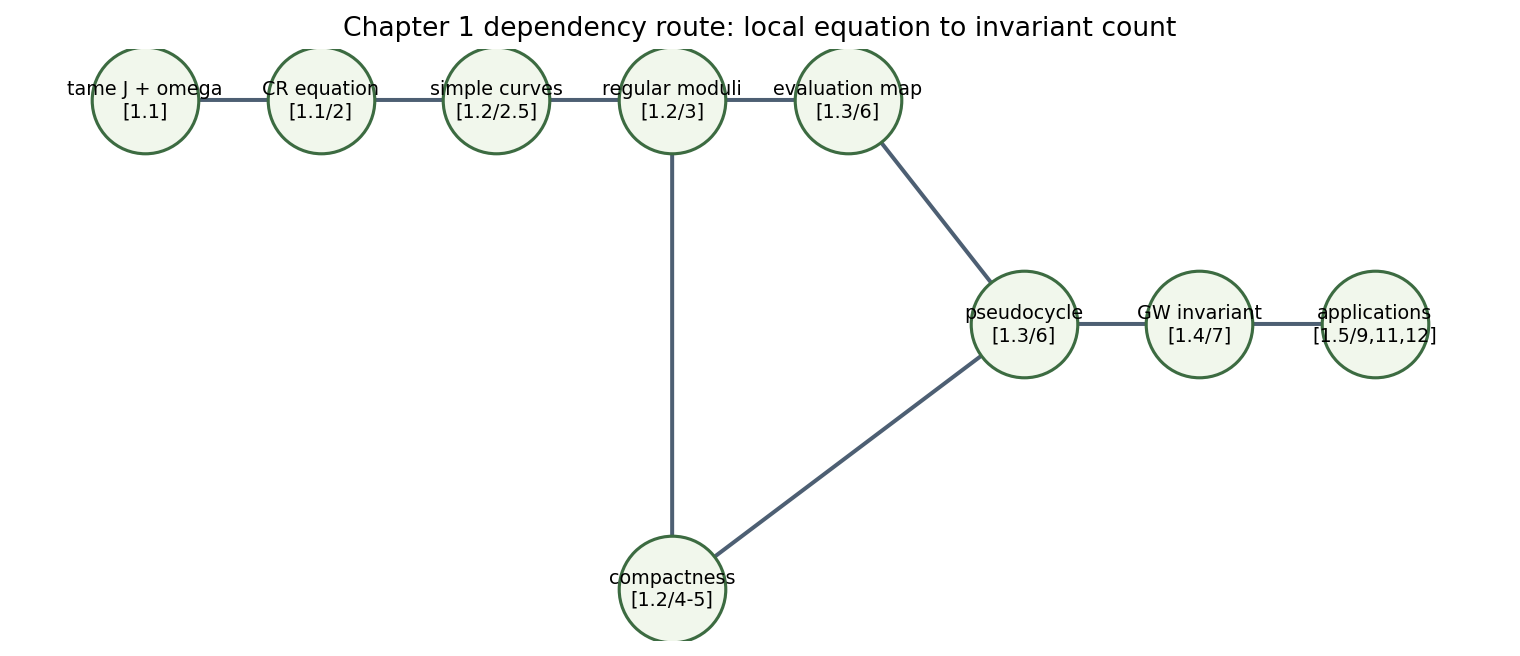

{'node_count': 9,
 'edge_count': 9,
 'all_nodes_have_source_anchor': True,
 'has_required_gates': True,
 'passed': True}

In [3]:
pipeline_nodes = {
    "tame J + omega": "1.1",
    "CR equation": "1.1/2",
    "simple curves": "1.2/2.5",
    "regular moduli": "1.2/3",
    "compactness": "1.2/4-5",
    "evaluation map": "1.3/6",
    "pseudocycle": "1.3/6",
    "GW invariant": "1.4/7",
    "applications": "1.5/9,11,12",
}
pipeline_edges = [
    ("tame J + omega", "CR equation"),
    ("CR equation", "simple curves"),
    ("simple curves", "regular moduli"),
    ("regular moduli", "evaluation map"),
    ("compactness", "pseudocycle"),
    ("evaluation map", "pseudocycle"),
    ("pseudocycle", "GW invariant"),
    ("GW invariant", "applications"),
    ("regular moduli", "compactness"),
]
G = nx.DiGraph()
for node, anchor in pipeline_nodes.items():
    G.add_node(node, anchor=anchor)
G.add_edges_from(pipeline_edges)
pos = {
    "tame J + omega": (0, 2),
    "CR equation": (1.4, 2),
    "simple curves": (2.8, 2),
    "regular moduli": (4.2, 2),
    "compactness": (4.2, 0.8),
    "evaluation map": (5.6, 2),
    "pseudocycle": (7.0, 1.45),
    "GW invariant": (8.4, 1.45),
    "applications": (9.8, 1.45),
}
fig, ax = plt.subplots(figsize=(12, 4.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#4d5f73")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2300, node_color="#f1f7ec", edgecolors="#3c6b41", linewidths=1.4)
labels = {node: f"{node}\n[{anchor}]" for node, anchor in pipeline_nodes.items()}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8.6)
ax.set_title("Chapter 1 dependency route: local equation to invariant count")
ax.set_axis_off()
graph_path = save_matplotlib(fig, UNIT, "figures", "gw-course-pipeline.png")
plt.close(fig)

graph_check = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "all_nodes_have_source_anchor": all(bool(data["anchor"]) for _, data in G.nodes(data=True)),
    "has_required_gates": all(node in G for node in ["regular moduli", "compactness", "evaluation map", "pseudocycle", "GW invariant"]),
    "passed": G.number_of_nodes() >= 8 and nx.has_path(G, "tame J + omega", "GW invariant"),
}
graph_check_path = save_json(graph_check, UNIT, "checks", "gw-pipeline-checks.json")
display_artifact(graph_path)
graph_check

## Evaluation Ledger: When a Moduli Space Can Be Counted

For a genus-zero class in a semipositive target, the introduction points toward a recurring dimension rule: an evaluation map becomes a counting device only when the expected moduli dimension and the codimensions of the constraints balance. The exact formulas are developed later; here the point is the habit of bookkeeping.

The toy ledger below uses the familiar projective-plane pattern: degree `d` rational curves have complex dimension `3d - 1` after quotienting by reparametrization, so `3d - 1` point constraints should leave a zero-dimensional count. The computation is not meant as a proof of the enumerative numbers. It teaches the gate: before asking for a count, check the dimension budget.


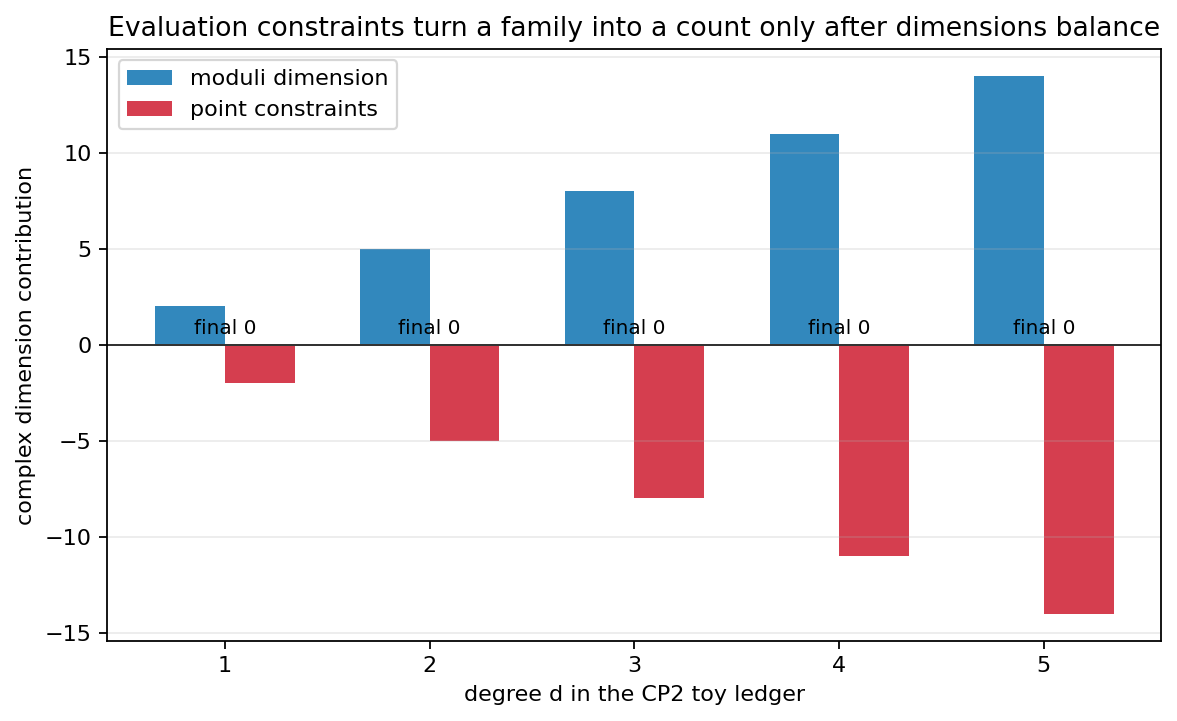

,degree,expected_complex_dim,point_constraints,final_complex_dim,count_ready
0,1,2,2,0,True
1,2,5,5,0,True
2,3,8,8,0,True
3,4,11,11,0,True
4,5,14,14,0,True


In [4]:
degrees = np.arange(1, 6)
rows = []
for d in degrees:
    expected_complex_dim = 3 * d - 1
    point_constraints = 3 * d - 1
    final_complex_dim = expected_complex_dim - point_constraints
    rows.append({
        "degree": int(d),
        "expected_complex_dim": int(expected_complex_dim),
        "point_constraints": int(point_constraints),
        "final_complex_dim": int(final_complex_dim),
        "count_ready": bool(final_complex_dim == 0),
    })
ledger = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
width = 0.34
ax.bar(degrees - width/2, ledger["expected_complex_dim"], width, label="moduli dimension", color="#3288bd")
ax.bar(degrees + width/2, -ledger["point_constraints"], width, label="point constraints", color="#d53e4f")
ax.axhline(0, color="#333", linewidth=0.9)
for d, final in zip(degrees, ledger["final_complex_dim"]):
    ax.text(d, 0.35, f"final {final}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(degrees)
ax.set_xlabel("degree d in the CP2 toy ledger")
ax.set_ylabel("complex dimension contribution")
ax.set_title("Evaluation constraints turn a family into a count only after dimensions balance")
ax.legend()
ax.grid(axis="y", alpha=0.25)
ledger_fig = save_matplotlib(fig, UNIT, "figures", "gw-dimension-ledger.png")
plt.close(fig)

table_path = TABLE_DIR / "invariant-ledger.csv"
ledger.to_csv(table_path, index=False)
ledger_check = {
    "rows": rows,
    "all_final_dimensions_zero": bool((ledger["final_complex_dim"] == 0).all()),
    "all_count_ready": bool(ledger["count_ready"].all()),
    "passed": bool((ledger["final_complex_dim"] == 0).all()),
}
ledger_json = save_json(ledger_check, UNIT, "checks", "invariant-ledger.json")
display_artifact(ledger_fig)
display_artifact(table_path)
ledger

## Applied Lab

Change the number of point constraints in the ledger cell from `3*d - 1` to `3*d - 2` or `3*d`. The graph will still render, but the final dimension check will stop saying that every row is count-ready. That is the intended failure: a visual count without a dimension check is just a picture.

A second experiment is to replace the standard `J0` in the taming cell with a small perturbation. If `J^2 = -I` or the positivity samples fail, the local model is no longer a legitimate tame almost complex structure and the rest of the pipeline should not be trusted.


## Takeaways

- Taming is the local positivity condition that lets the Cauchy-Riemann equation interact with symplectic area.
- Regularity and compactness solve different problems: one gives dimension, the other controls limits.
- Evaluation maps are the bridge from moduli spaces to cycles, and Gromov-Witten invariants are intersection numbers after the dimension and compactness gates have been passed.
- The introductory chapter is a route map for later notebooks: Chapters 2-6 build the analytic and compactness machinery, Chapter 7 defines the counts, Chapters 9-12 show what those counts can do.


## Sanity Checks

The final cell asserts every concept artifact used by the chapter, checks the JSON invariants, and writes `final-sanity.json`. The checks are intentionally redundant: they protect against stale paths, decorative visuals with no backing invariant, and notebooks that look complete but have not actually generated their local assets.


In [5]:
assert_artifact(FIG_DIR / "taming-positive-area.png", min_bytes=512)
assert_artifact(FIG_DIR / "gw-course-pipeline.png", min_bytes=512)
assert_artifact(FIG_DIR / "gw-dimension-ledger.png", min_bytes=512)
assert_artifact(CHECK_DIR / "source-coverage.json", min_bytes=80)
assert_artifact(CHECK_DIR / "visual-storyboard.json", min_bytes=80)
assert_artifact(CHECK_DIR / "taming-area-checks.json", min_bytes=80)
assert_artifact(CHECK_DIR / "gw-pipeline-checks.json", min_bytes=80)
assert_artifact(CHECK_DIR / "invariant-ledger.json", min_bytes=80)
assert_artifact(TABLE_DIR / "invariant-ledger.csv", min_bytes=80)

check_paths = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "taming-area-checks.json",
    CHECK_DIR / "gw-pipeline-checks.json",
    CHECK_DIR / "invariant-ledger.json",
]
loaded_checks = {path.name: json.loads(path.read_text(encoding="utf-8")) for path in check_paths}
assert all(data.get("passed") is True for data in loaded_checks.values())
assert all(row["final_complex_dim"] == 0 for row in loaded_checks["invariant-ledger.json"]["rows"])
assert loaded_checks["taming-area-checks.json"]["minimum_omega_v_Jv"] > 0

final_sanity = {
    "unit": UNIT,
    "artifact_count": 9,
    "checks": sorted(loaded_checks),
    "all_checks_passed": True,
    "standalone_markers": ["Source Coverage", "Library Routing", "Applied Lab", "Takeaways"],
    "passed": True,
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(final_sanity_path, min_bytes=80)
print(f"Validated {final_sanity['artifact_count']} Chapter 1 artifacts")

Validated 9 Chapter 1 artifacts
